## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 4.5 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

## Import Dataset

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
visa = pd.read_csv('EasyVisa.csv') ##  Fill the blank to read the data

In [ ]:
# copying data to another variable to avoid any changes to original data
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [ ]:
data.head() ##  Complete the code to view top 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail() ##  Complete the code to view last 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [ ]:
data.shape ##  Complete the code to view dimensions of the data

(25480, 12)

### Observations:
* The dataset has 25480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


## Observations:
* There are only 3 numerical variables
* There are no null (missing) values

In [ ]:
# checking for duplicate values
data.duplicated().sum() ##  Complete the code to check duplicate entries in the data

np.int64(0)

## Observations:
 * ## There are no duplicate values

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [ ]:
data.describe().T ##  Complete the code to print the statistical summary of the data

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


## Observations:
* `no_of_employee` column: There are negative values in the number of employee column. Will need to fix
* `yr_of_estab`: The companies year of establishment ranges from 1800 to 2016
* `prevailing_wage`: Median year of establishment is 1997
* Prevailing wage ranges from 2.1367 to 319,210.27.
* With median wage being USD 70,308.21 and the average not too far at USD 74,455.82. This indicates outliers due to variation in employment roles.

#### Fixing the negative values in number of employees columns

In [ ]:
# checking the shape (number of rows and columns) of all negative values (< 0)
data.loc[data['no_of_employees'] < 0].shape

(33, 12)

### Observations:
* There are 33 rows with negative values in this column. Ths is an error.  Fixing it below

In [ ]:
# Viewing the negative values rows in the employee column
# using .loc
data.loc[data['no_of_employees'] < 0]

#data.loc['_______'].shape #

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [ ]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"]) ## Write the function to convert the values to a positive number

In [ ]:
# Checking the statistical summary again
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.089207,22877.917453,11.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


### Observations:
* `no_of_employees`: The number of employees at the employer's company ranges widely from 11 to 602,069.
* The avg employee size is 5667. Still about the same before the negative values got fixed.

In [ ]:
# checking the shape (number of rows and columns) of all negative values (< 0) again
data.loc[data['no_of_employees'] < 0].shape

(0, 12)

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

### Observations:
* `case_id` is a unique identifier and will be dropped.

In [ ]:
# checking the number of unique values. # Complete the code to check unique values in the mentioned column
data['case_id'].nunique()

#data["case_id"].'_______' #

25480

In [ ]:
data.drop(["case_id"], axis=1, inplace=True) ## Complete the code to drop 'case_id' column from the data

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

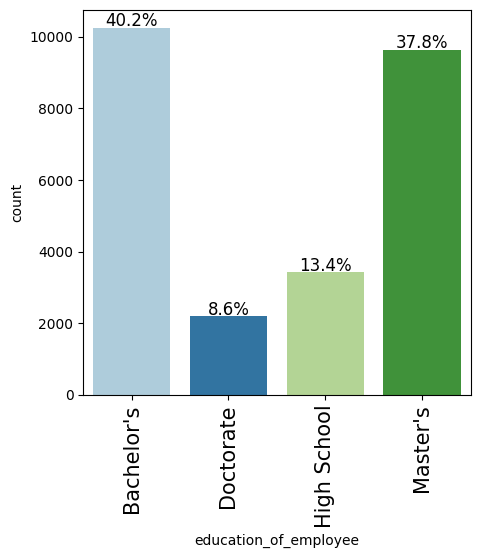

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)

### Observations:
* A majority of employees hold either a Bachelor's (40.2%) or Master's degree (37.8%), suggesting a highly educated workforce.

* Employees with Doctorate degrees form the smallest group at 8.6%, indicating fewer roles requiring such high-level qualifications or few employees are available with the highest degree.

#### Observations on region of employment

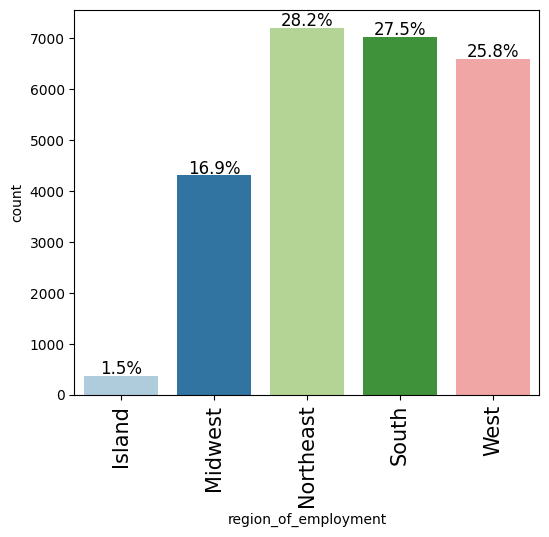

In [ ]:
labeled_barplot(data, 'region_of_employment', perc = True)  ## Complete the code to create labeled_barplot for region of employment

### Observations:
* The Northeast (28.2%) and South (27.5%) regions have the highest number of employees, collectively accounting for over half of the workforce.
* The West (25.8%) is not a distant third.

* The Island region has the smallest employee representation, at only 1.5%, suggesting either limited job opportunities or smaller business presence in this region.

#### Observations on job experience

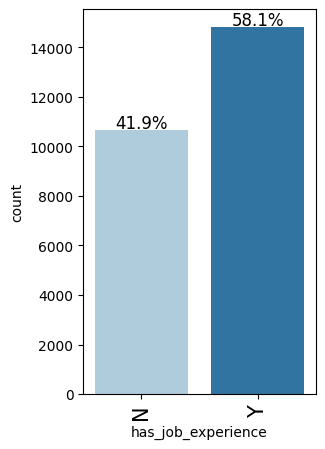

In [ ]:
labeled_barplot(data, 'has_job_experience', perc = True) ## Complete the code to create labeled_barplot for job experience

### Observations:
* Only 58.1% of employee has job experience.

#### Observations on case status

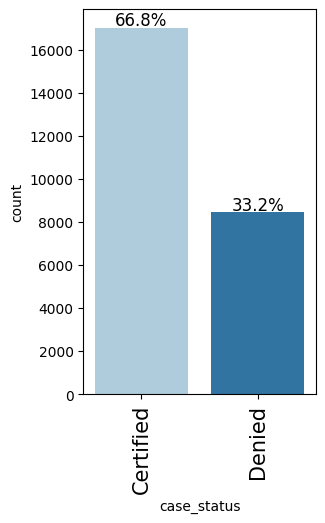

In [ ]:
labeled_barplot(data, 'case_status', perc = True) ## Complete the code to create labeled_barplot for case status

### Observations:
* 66.8% of employee Visa applications were Certified. Suggesting an imbalanced dataset

### Bivariate Analysis

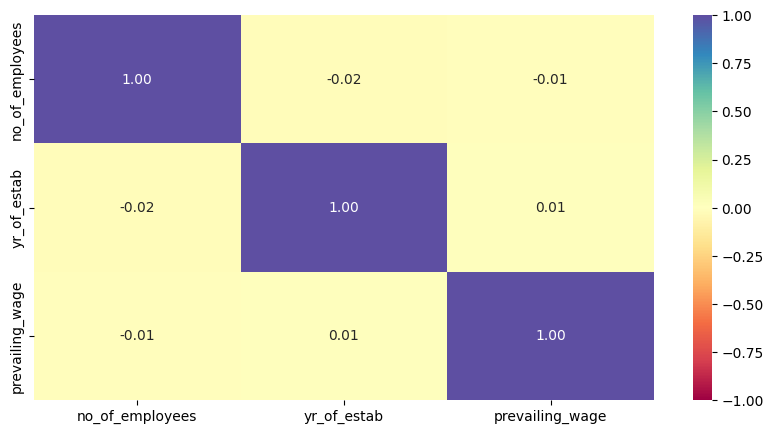

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
) ## Complete the code to find the correlation between the variables - Added ".corr()"
plt.show()

### Observations:
* There are no strong correlations observed among the numerical variables

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


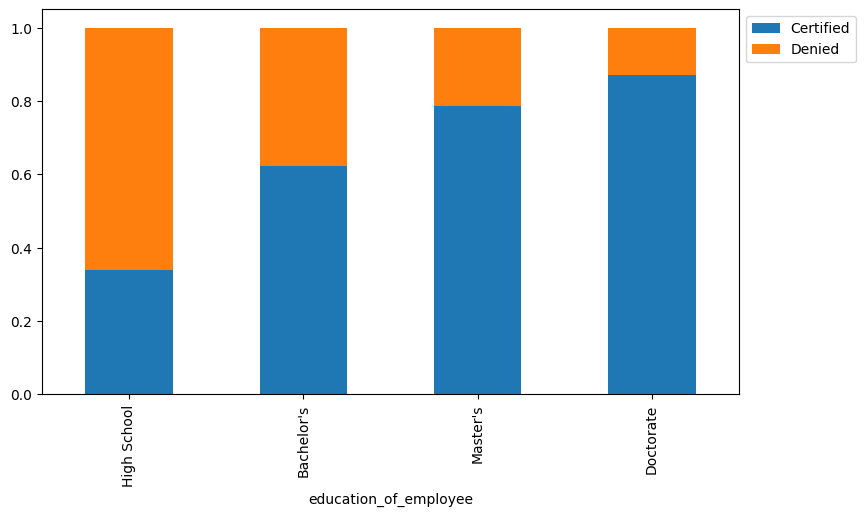

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

### Observations:
* Higher education correlates with higher approval (certification) rates:

  * Doctorate holders have the highest approval rate (appr 87%), followed by Master’s holders (appr 78%).

  * High School graduates have the lowest approval rate (appr.
 34%), indicating a strong preference for advanced degrees in certification decisions.

* Volume vs. approval trade-off:

  * Although Bachelor’s degree holders have the highest number of applications, their certification rate (appr. 62%) is lower than those with graduate degrees.

* These suggest that higher education significantly improves one’s chances of certification.

#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


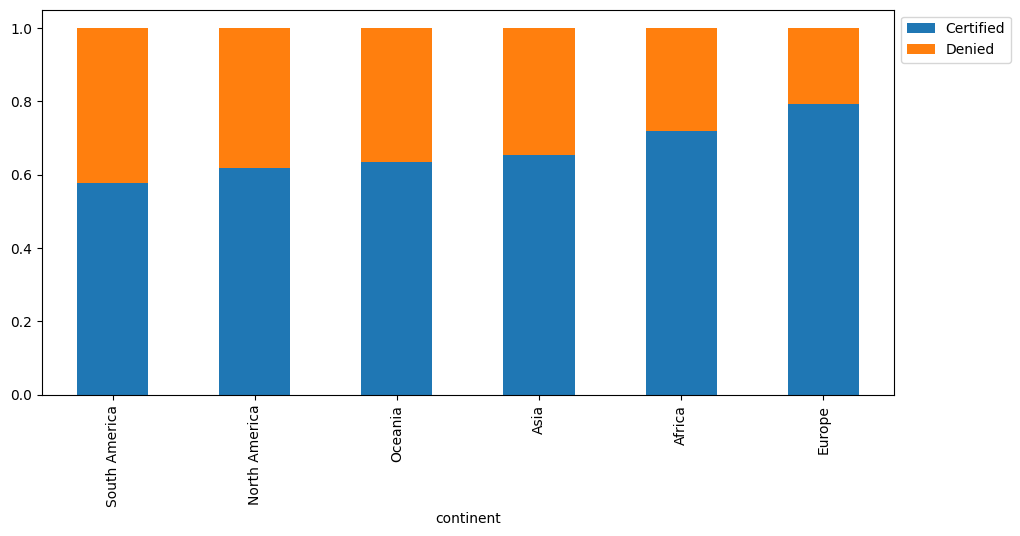

In [ ]:
stacked_barplot(data, "continent", "case_status") ## Complete the code to plot stacked barplot for region of continent and case status

## Observations:
* Europe leads in certification rate: With ~79% of applications certified, Europe has the highest success rate among all continents.

* South America has the lowest certification rate: Only about 58% of applications are certified, the lowest among all regions. Could this be possible eligibility or documentation challenges?

* Asia has the highest application volume: Over 16,800 applications, accounting for nearly two-thirds of the total, came from Asia. While the certification rate is moderate (~65%), this region drives most of the overall demand.

#### Recommendation:

* These insights can guide targeted outreach and support strategies by continent to improve certification outcomes and streamline processing

#### Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Let's see if having work experience has any influence over visa certification

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


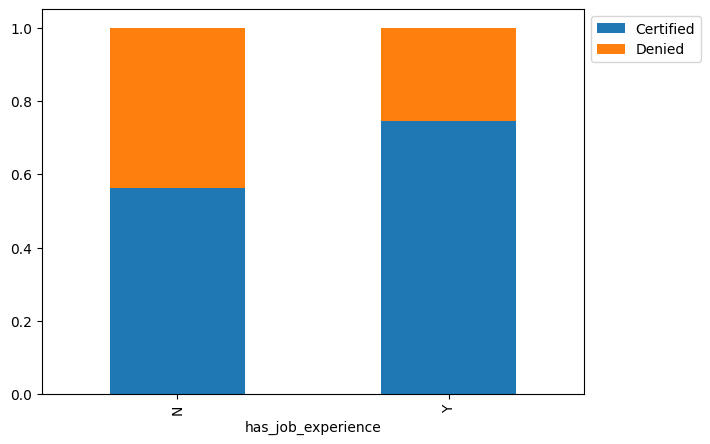

In [ ]:
stacked_barplot(data, 'has_job_experience', 'case_status') ## Complete the code to plot stacked barplot for region of case_status and has_job_experience

### Observation:

* Applicants with prior job experience (Y) have a noticeably higher certification rate (about 74%) compared to those without job experience (N), whose certification rate is around 56%.

* This indicates that job experience is a strong positive factor influencing visa approval.

* This insight can help the model assign higher weights to the has_job_experience feature during classification and guide applicants on how prior experience improves approval chances.

#### Checking if the prevailing wage is similar across all the regions of the US

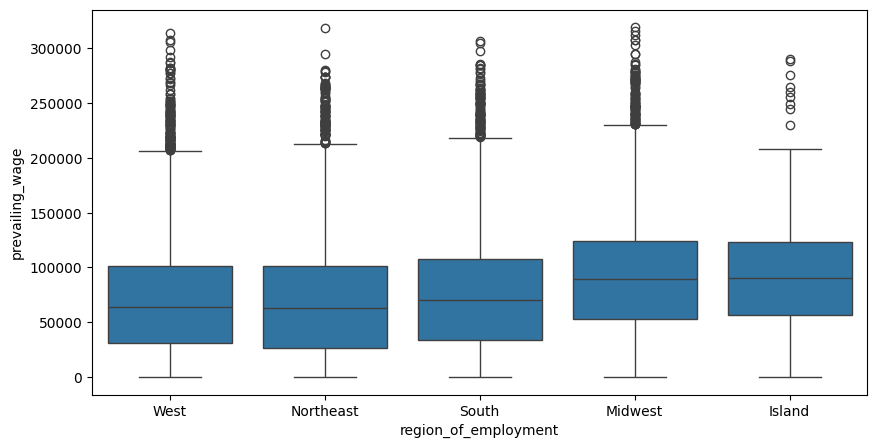

In [ ]:
#plt.figure(figsize=(10, 5))
#sns.'_______' ## Complete the code to create boxplot for region of employment and prevailing wage
#plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='region_of_employment', y='prevailing_wage', data=data)
plt.show()

### Observation:

* Median wages vary across regions, with the Midwest showing the highest median prevailing wage compared to others.

* West and Northeast have slightly lower medians, while Island and South regions exhibit broader wage ranges but slightly lower medians than the Midwest.

* All regions show a high number of outliers, suggesting significant wage variance, particularly in high-paying jobs.

* While the general wage range overlaps, the distribution and medians differ, indicating regional wage disparities that could affect visa evaluation and employer expectations.

#### The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage

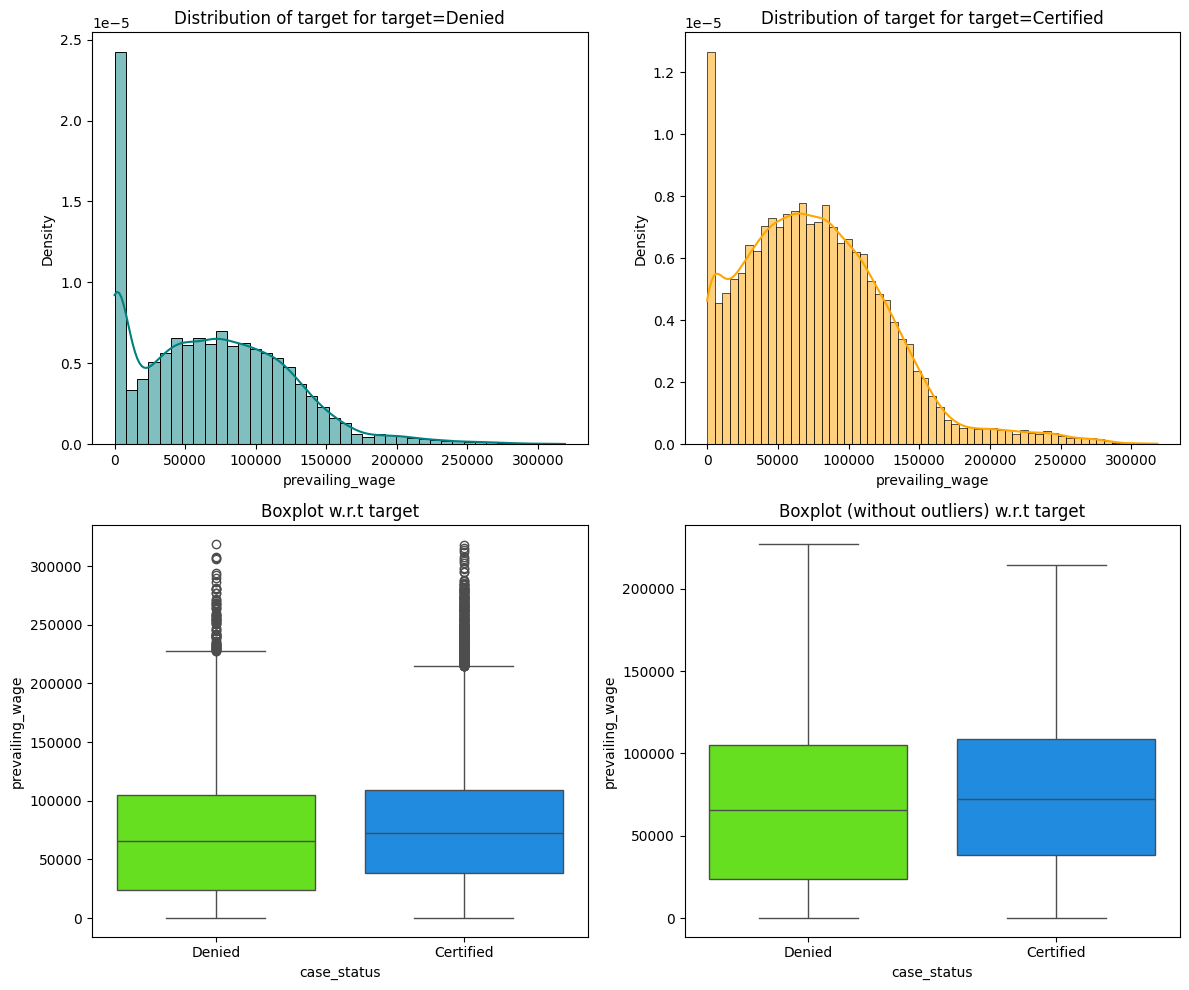

In [ ]:
distribution_plot_wrt_target(data, 'prevailing_wage', 'case_status') ## Complete the code to find distribution of prevailing wage and case status

### Observation

* Yes, Visa case status is influenced by the prevailing wage. Higher prevailing wages are positively associated with visa certification outcomes. This indicates that wage offered plays a significant role in OFLC’s decision-making process

* Certified applications tend to have higher prevailing wages compared to Denied ones.

* The density plots (top row) show a right-skewed distribution in both categories, but the Certified group shifts towards higher wage values, especially beyond $60,000.

* The boxplots (bottom row) confirm that median wages are higher for Certified cases, and the wage distribution is more spread out.

* Even after removing outliers, the Certified group still maintains a higher interquartile range, reinforcing wage as a key differentiator in visa approval.

#### The prevailing wage has different units (Hourly, Weekly, etc). Let's find out if it has any impact on visa applications getting certified.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


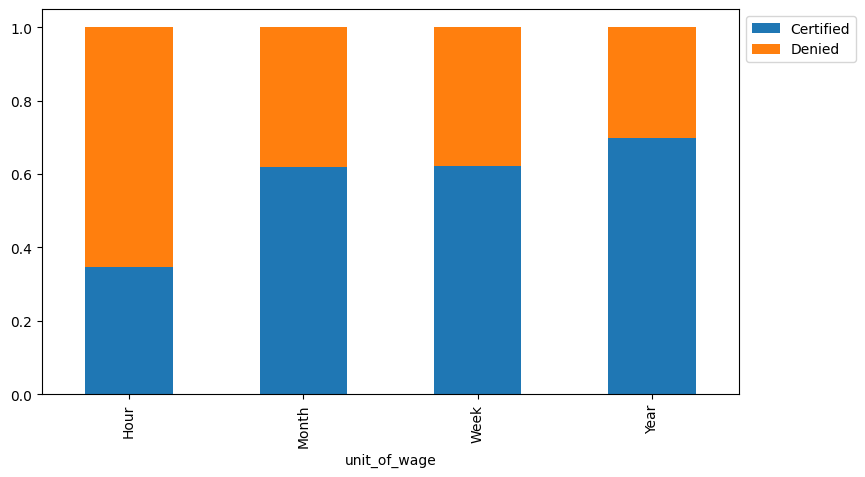

In [ ]:
stacked_barplot(data, 'unit_of_wage', 'case_status') ## Complete the code to plot stacked barplot for unit of wage and case status

### Observations:
* Yearly wage units have the highest approval rate (~70% certified).

* Hourly wage units have the lowest approval rate, with more denials than certifications (~65% denied).

* Weekly and Monthly units fall in between but lean toward higher certification rates (~62%).

## Data Pre-processing

### Outlier Check

- Let's check for outliers in the data.

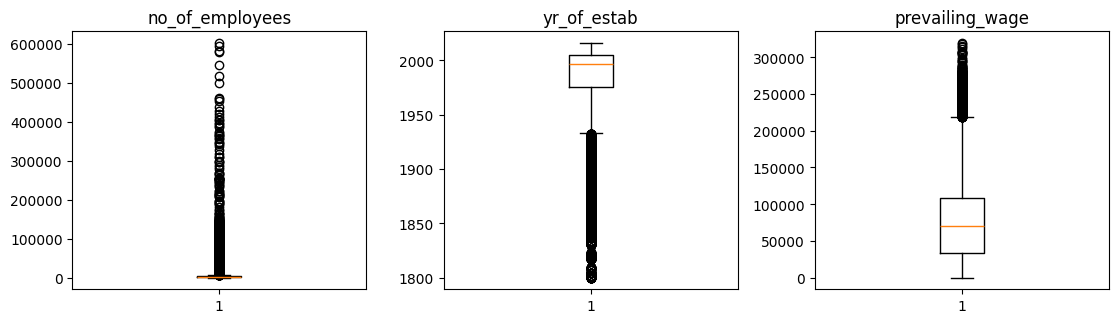

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Data Preparation for modeling

- We want to predict which visa will be certified.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [ ]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(["case_status"], axis=1) ## Complete the code to drop case status from the data
y = data["case_status"]


X = pd.get_dummies(X, drop_first=True)  ## Complete the code to create dummies for X

# Complete the code to split the dataset into train and valid with a ratio of 7:3
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# # Complete the code to split the dataset into valid and test with a ratio of 9:1
X_val,X_test,y_val,y_test = train_test_split(
    X_val,y_val,test_size=0.1,random_state=1,stratify=y_val
)


In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

Provide some reasoning for choosing the metric here : ______

**Model can make wrong predictions as:**

1. Predicting a visa application as certified when it should
be denied – This could lead to non-eligible candidates receiving approval, which may raise compliance risks.

2. Predicting a visa application as denied when it should be certified – This results in qualified candidates being rejected, leading to missed opportunities for employers to fill critical skill gaps.

**Which case is more important?**

* Predicting a visa application as denied when it should be certified – i.e., missing out on a qualified candidate who could have been placed in a role urgently needed by a U.S. employer. This leads to economic and operational loss for both the company and the applicant.

**How to reduce this loss i.e. need to reduce False Negatives?**

* The aim is to maximize Recall, as a higher recall means fewer certified cases will be wrongly denied. However, we must also ensure Precision is not too low to avoid approving unqualified applicants.

**Model Evaluation Criteria:**

We will evaluate our model using:

* F1-Score: To strike a balance between Recall and Precision.


First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [ ]:
scorer = metrics.make_scorer(metrics.f1_score) ## Complete the code to define the metric

## Possible metrics are [recall_score,f1_score,accuracy_score,precision_score]
## For example, metrics.precision_score

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier (estimator = DecisionTreeClassifier(random_state = 1, class_weight='balanced'), random_state=1))) # I added estimator, so I can add class_weight as a parameter to tweak the model
models.append(("Random forest",RandomForestClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Random Forest Classifier with random_state of 1. - I added class_weight='balanced'
models.append(("GBM", GradientBoostingClassifier(random_state=1))) ## Complete the code to add Gradient Boosting Classifier with random_state of 1.
models.append(("Adaboost", AdaBoostClassifier(random_state=1))) ## Complete the code to add AdaBoost Classifier with random_state of 1.
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Decision Tree Classifier with random_state of 1. - I added class_weight='balanced'

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits= 5, shuffle=True, random_state=1
    )  # Complete the code to set the number of splits.
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring = scorer,cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train) ## Complete the code to fit the model on X_train and y_train
    scores = f1_score(y_val, model.predict(X_val)) ## Complete the code to define the metric function name.
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.7795174942234298
Random forest: 0.8045334827520751
GBM: 0.823039791269532
Adaboost: 0.8203377989495703
Xgboost: 0.8073583989766158
dtree: 0.7448931643789144

Validation Performance:

Bagging: 0.7717968157695224
Random forest: 0.8035695755940645
GBM: 0.8195818459969403
Adaboost: 0.8158053488839735
Xgboost: 0.8070320579110651
dtree: 0.7421138211382113


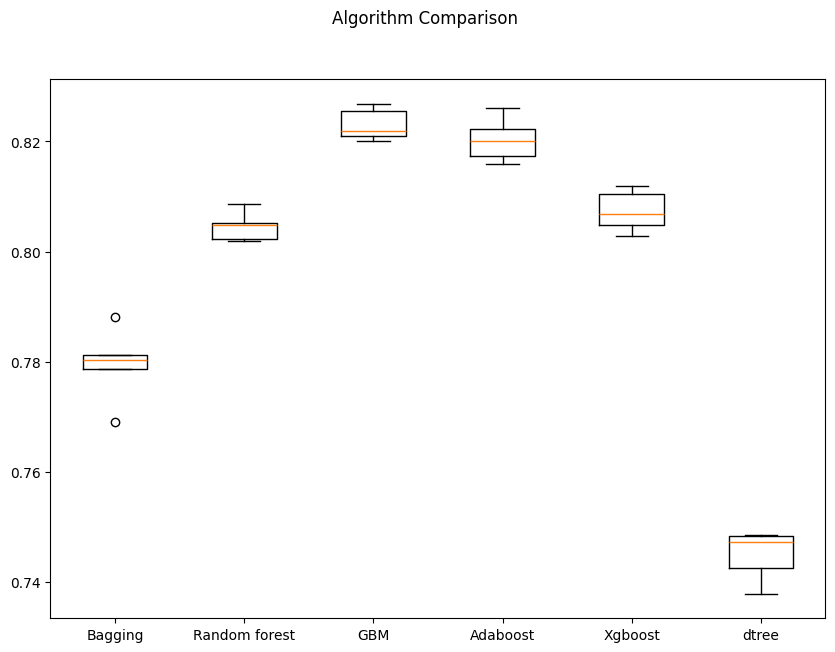

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Observations:

* GBM is the best performing model in both training and validation based on F1-score.

* AdaBoost and XGBoost also perform well, offering strong alternatives.

* Decision Tree consistently performs the worst, reaffirming it's too simple for this problem.

* Bagging lags behind ensemble boosting methods, potentially due to weaker individual learners.

### Model Building with oversampled data

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy= 1, k_neighbors= 5, random_state=1) ## Complete the code to set the k-nearest neighbors and sampling strategy
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list - Also added class_weight as a parameter and set it to 'balanced' on BaggingClassifier, RandomForest, and dtree
models.append(("Bagging", BaggingClassifier(estimator = DecisionTreeClassifier(random_state = 1, class_weight='balanced'), random_state=1)))
models.append(("Random forest",RandomForestClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Random Forest Classifier with random_state of 1.
models.append(("GBM", GradientBoostingClassifier(random_state=1))) ## Complete the code to add Gradient Boosting Classifier with random_state of 1.
models.append(("Adaboost", AdaBoostClassifier(random_state=1))) ## Complete the code to add AdaBoost Classifier with random_state of 1.
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Decision Tree Classifier with random_state of 1.

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits= 5, shuffle=True, random_state=1
    )  ## Complete the code to set the number of splits
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over) ## Complete the code to fit the model on the oversampled data.
    scores = f1_score(y_val, model.predict(X_val)) ## Complete the code to define the metric function name.
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.7556376199513684
Random forest: 0.7938138292522969
GBM: 0.8076949280007495
Adaboost: 0.8013161599972107
Xgboost: 0.799430071068073
dtree: 0.7236738310580881

Validation Performance:

Bagging: 0.7606724176067242
Random forest: 0.7953896584540552
GBM: 0.8125259228535877
Adaboost: 0.8120255086547221
Xgboost: 0.8039950062421972
dtree: 0.7387687188019967


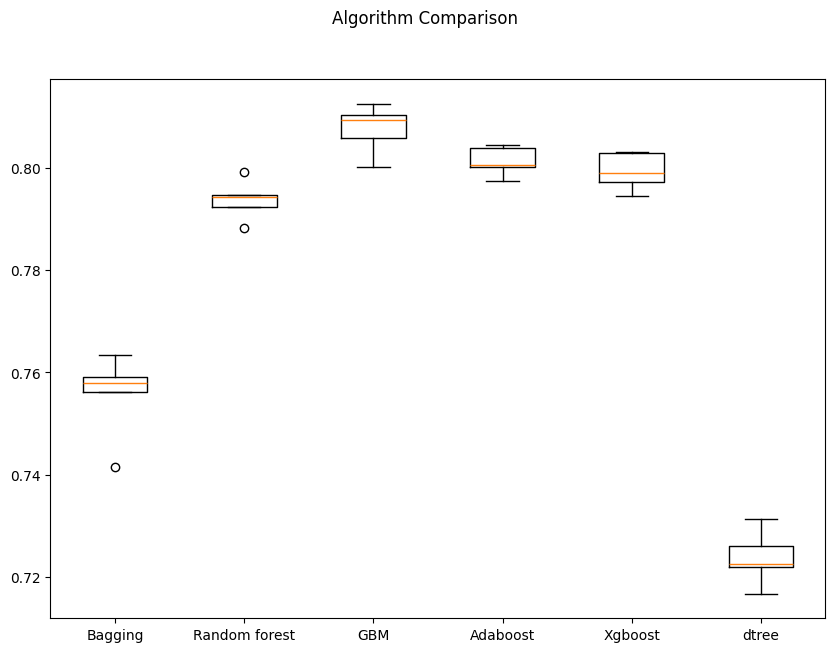

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Observation:
* GBM has the best performance on validation followed by AdaBoost

### Model Building with undersampled data

In [ ]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator = DecisionTreeClassifier(random_state = 1, class_weight='balanced'), random_state=1)))
models.append(("Random forest",RandomForestClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Random Forest Classifier with random_state of 1.
models.append(("GBM", GradientBoostingClassifier(random_state=1))) ## Complete the code to add Gradient Boosting Classifier with random_state of 1.
models.append(("Adaboost", AdaBoostClassifier(random_state=1))) ## Complete the code to add AdaBoost Classifier with random_state of 1.
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced'))) ## Complete the code to add Decision Tree Classifier with random_state of 1.

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits= 5, shuffle=True, random_state=1
    )  ## Complete the code to set the number of splits
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un,scoring = scorer, cv=kfold,n_jobs =-1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un) ## Complete the code to fit the model on the undersampled data.
    scores = f1_score(y_val, model.predict(X_val)) ## Complete the code to define the metric function name.
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.642537896710199
Random forest: 0.6865639509715183
GBM: 0.7131358906535971
Adaboost: 0.6949405744215158
Xgboost: 0.6944693136408734
dtree: 0.6151388244082543

Validation Performance:

Bagging: 0.6916956737941323
Random forest: 0.734144015259895
GBM: 0.7608695652173914
Adaboost: 0.7604202747950584
Xgboost: 0.7423652871123688
dtree: 0.6839080459770115


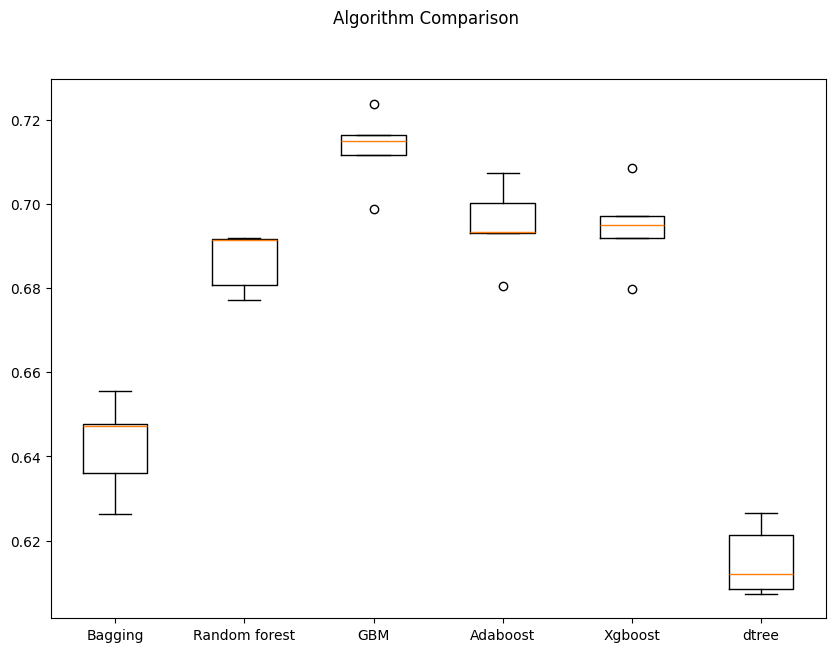

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

###Observations:

* GBM has the best performance followed by AdaBoost model as per the validation performance

* After building 18 models, it was observed that both the GBM and Adaboost models, trained on an undersampled dataset, as well as the GBM model trained on an oversampled dataset, exhibited strong performance on both the training and validation datasets.
* Sometimes models might overfit after undersampling and oversampling, so it's better to tune the models to get a generalized performance
* We will tune these 3 models using the same data (undersampled or oversampled) as we trained them on before

## Hyperparameter Tuning

### Tuning AdaBoost using oversampled data

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(30, 110, 20), ## Complete the code to set the number of estimators
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5, 1], ## Complete the code to set the learning rate.
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv= 5, random_state=1)  ## Complete the code to set the cv parameter

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over) ## Complete the code to fit the model on over sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(90), 'learning_rate': 1, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.7984283842220219:
CPU times: user 7.62 s, sys: 863 ms, total: 8.49 s
Wall time: 6min 26s


In [ ]:
## Complete the code to set the best parameters.
tuned_ada = AdaBoostClassifier(
    n_estimators= 90,
    learning_rate= 1,
    estimator= DecisionTreeClassifier(max_depth=2, random_state=1)
)

tuned_ada.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=1, n_estimators=90)

In [ ]:
ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.787669,0.841014,0.759936,0.798422


In [ ]:
## Complete the code to check the model performance for validation data.
ada_val_perf = model_performance_classification_sklearn(tuned_ada,X_val,y_val)
ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.734118,0.839356,0.779462,0.808301


### Observations:
* The training performance shows the model favored higher recall (84.1%), which is important as we want to minimize false negatives.
* The model generalized well when evaluated on the validation set. The validation F1-score (0.8083) is even slightly higher than the training set (0.7984), which is a positive indicator. It suggests the model is not overfitting despite being trained on oversampled data.
* The model maintains high recall on both training and validation sets → aligns with your business objective.

* F1-score is stable across sets (≈0.80) → good balance between precision and recall.

### Tuning Random forest using undersampled data

In [ ]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [100, 150, 200, 250], ## Complete the code to set the number of estimators.
    "min_samples_leaf": np.arange(1, 10, 1), ## Complete the code to set the minimum number of samples in the leaf node.
    "max_features": [np.arange(3, 10, 1),'sqrt'], ## Complete the code to set the maximum number of features.
    "max_samples": np.arange(0.2, 1, 0.1)} ## Complete the code to set the maximum number of samples.


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv= 5, random_state=1) ## Complete the code to set the cv parameter

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un) ## Complete the code to fit the model on under sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 150, 'min_samples_leaf': np.int64(5), 'max_samples': np.float64(0.30000000000000004), 'max_features': 'sqrt'} with CV score=0.7217872867203423:
CPU times: user 3.69 s, sys: 498 ms, total: 4.19 s
Wall time: 3min 10s


In [ ]:
# Complete the code to define the best model
tuned_rf2 = RandomForestClassifier(
    max_features= 'sqrt',
    random_state= 1,
    max_samples= 0.3,
    n_estimators= 150,
    min_samples_leaf= 5,
)

tuned_rf2.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.3, min_samples_leaf=5, n_estimators=150,
                       random_state=1)

In [ ]:
rf2_train_perf = model_performance_classification_sklearn(
    tuned_rf2, X_train_un, y_train_un
)
rf2_train_perf

,Accuracy,Recall,Precision,F1
0,0.749873,0.77427,0.738249,0.75583


In [ ]:
## Complete the code to print the model performance on the validation data.
rf2_val_perf = model_performance_classification_sklearn(tuned_rf2, X_val, y_val)
rf2_val_perf

,Accuracy,Recall,Precision,F1
0,0.71115,0.731824,0.816614,0.771898


### Observations:
* There's no major performance drop from training to validation, indicating low overfitting.

* The training performance shows the model favored higher recall (77.4%), than other evaluation metrics. This is still important to minimize false negatives.

* Again, the model generalized well when evaluated on the validation set. The validation F1-score (0.7719) is even slightly higher than the training set (0.7558), which is a positive indicator. It suggests the model is not overfitting despite being trained on oversampled data.

* The precision also scored higher on validation set (81.66%) to the training set (73.8%). Meaning the model is making fewer false positives.

* The model maintains high recall on both training and validation sets → aligns with your business objective.

* F1-score improvement: The F1 score rose from training to validation, suggesting your tuned parameters and balanced dataset are working well together.

### Tuning with Gradient boosting with oversampled data

In [ ]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

## Complete the code to define the hyper parameters.
param_grid={"n_estimators": np.arange(50, 201, 25),
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "subsample":[0.6, 0.8, 1.0],
            "max_features":['sqrt', 0.6,0.8]}

## Complete the code to set the cv parameter.
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring=scorer, n_iter=50, n_jobs = -1, cv= 5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(175), 'max_features': 0.8, 'learning_rate': 0.1} with CV score=0.8024561078014825:
CPU times: user 13.2 s, sys: 1.41 s, total: 14.6 s
Wall time: 10min 22s


In [ ]:
## Complete the code to define the best model.
tuned_gbm = GradientBoostingClassifier(
    max_features=0.8,
    random_state=1,
    learning_rate=0.1,
    n_estimators=175,
    subsample=0.8
)

tuned_gbm.fit(X_train_over, y_train_over)

GradientBoostingClassifier(max_features=0.8, n_estimators=175, random_state=1,
                           subsample=0.8)

In [ ]:
gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.802401,0.864434,0.769024,0.813942


In [ ]:
## Complete the code to print the model performance on the validation data.
gbm_val_perf = model_performance_classification_sklearn(tuned_gbm,X_val, y_val)
gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.738916,0.851545,0.778353,0.813306


###Observations:

* High F1 Score (0.813) on validation: This is one of the best performing models so far in terms of balancing precision and recall.

* Recall is very high (0.851): This means the model is excellent at minimizing false negatives — which aligns with the goal of not missing qualified candidates.

* Slight drop in accuracy from train to validation: This is expected and healthy — the model is generalizing well, not overfitting.

* Minimal overfitting: The F1 score on train and validation is nearly identical.

### Tuning XGBoost using oversampled data

In [ ]:
%%time

# defining model
Model = XGBClassifier(random_state=1,eval_metric='logloss')

## Complete the code to define the hyperparameters
param_grid={'n_estimators':[100, 150, 200, 250, 300],
            'scale_pos_weight':[1, 2, 3],
            'learning_rate':[0.01, 0.05, 0.1, 0.2],
            'gamma':[0, 0.1, 0.2, 0.5],
            'subsample':[0.7, 0.8, 0.9, 1.0]}

## Complete the code to set the cv parameter
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)## Complete the code to fit the model on over sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 100, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.813894202282847:
CPU times: user 3.48 s, sys: 495 ms, total: 3.97 s
Wall time: 2min 34s


In [ ]:
## Complete the code to define the best model
xgb2 = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    subsample=1,
    scale_pos_weight=3,
    n_estimators=100,
    learning_rate=0.2,
    gamma=0,
)

xgb2.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb2_train_perf = model_performance_classification_sklearn(
    xgb2, X_train_over, y_train_over
)
xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.803996,0.98892,0.721919,0.834585


In [ ]:
## Complete the code to print the model performance on the validation data.
xgb2_val_perf = model_performance_classification_sklearn(xgb2,X_val, y_val)
xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.710714,0.958206,0.71,0.815638


###Observations:

* F1-Score is highest among the models tested so far.
* High F1 = good balance of catching true positives without too many false positives.
* Very high Recall on the training set — almost all actual positives (visa certifications) are correctly identified at 98.9% in training, and 95.8% on validation set. However, slight tradeoff in Precision, but still solid.
* Very strong generalization: the drop from train to validation is reasonable. Not overfitting.

**We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.**

## Model performance comparison and choosing the final model

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_train_perf.T,
        xgb2_train_perf.T,
        ada_train_perf.T,
        rf2_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.802401,0.803996,0.787669,0.749873
Recall,0.864434,0.988920,0.841014,0.774270
Precision,0.769024,0.721919,0.759936,0.738249
F1,0.813942,0.834585,0.798422,0.755830


In [ ]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm_val_perf.T,
        xgb2_val_perf.T,
        ada_val_perf.T,
        rf2_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.738916,0.710714,0.734118,0.711150
Recall,0.851545,0.958206,0.839356,0.731824
Precision,0.778353,0.710000,0.779462,0.816614
F1,0.813306,0.815638,0.808301,0.771898


### Observations:
* XGBoost tuned with oversampled data, considering the priority on recall and F1-score.

In [ ]:
## Complete the code to print the model performance on the test data by the best model.
test = model_performance_classification_sklearn(xgb2, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.712418,0.958904,0.711176,0.816667


### Observations:

* Model Selection: Selected the XGBoost with oversampled data.
* Performed very well on the unseen data. COnsistent with the train and validation sets.
* Strong F1-score (0.817): This confirms a strong balance between recall and precision, especially ideal in a scenario where both correct identification and coverage matter.
* The model is well generalized, with F1-score around 0.81–0.83 throughout.

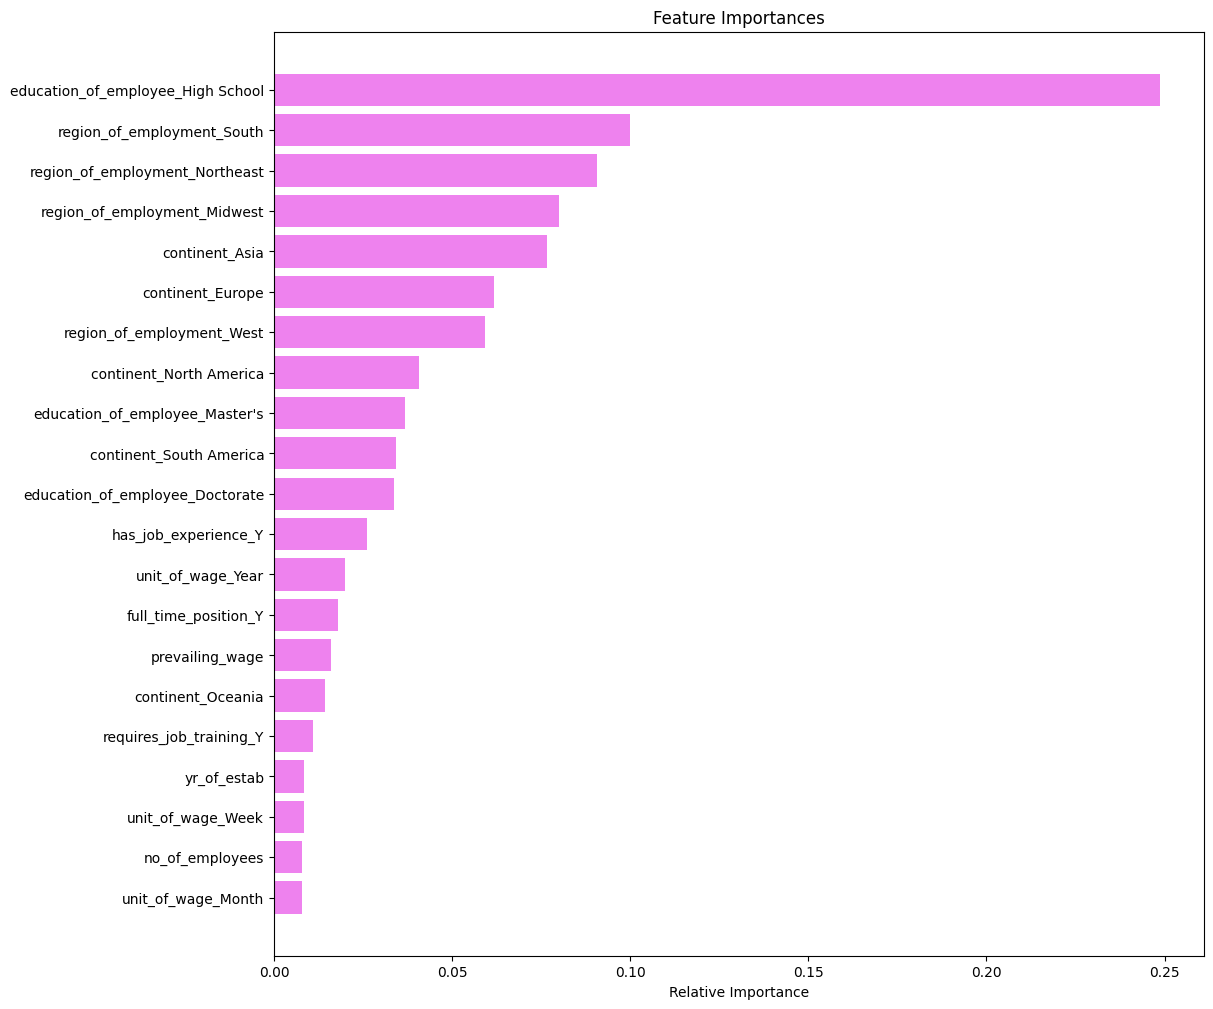

In [ ]:
feature_names = X_train.columns
importances = xgb2.feature_importances_ ## Complete the code to print the feature importances from the best model.
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

<font size=6 color='blue'>Power Ahead</font>
___